[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxischa/Intelligence-Artificielle-et-Data-Science/blob/main/bloc3_ml/cours/seance1_cours.ipynb)

# Séance 3.1 — Prédire un nombre, prédire une décision

**Cours** · durée : 2h (≈55 min de cours, ≈45 min d'exercices)

> ⚠️ **Avant de taper quoi que ce soit :** *Fichier → Enregistrer une copie dans Drive*. Sinon votre travail sera perdu en fermant l'onglet.
>
> 📱 Sur tablette, faites d'abord les réglages de [Bien démarrer](https://github.com/maxischa/Intelligence-Artificielle-et-Data-Science/blob/main/ressources/setup_tablette.md).

## Objectifs

À la fin de cette séance, vous saurez :

- dire ce qui sépare un modèle qui explique d'un modèle qui prédit
- découper en apprentissage et test, et dire pourquoi la note sur le test est la seule note qui compte
- mesurer une erreur en euros (MAE, RMSE, R²) et repérer une fuite de données
- ajuster une régression logistique et lire une matrice de confusion
- choisir un seuil de décision à partir d'un coût, pas d'une habitude

## Prédire n'est pas expliquer

Jusqu'ici, vous avez **décrit** des données : combien, par qui, dans quel
marché. Une question de gestion en appelle une autre :

> *« Cette commande qui arrive, combien va-t-elle rapporter ? »*
> *« Cet abonné, va-t-il résilier ? »*

Ces deux questions portent sur des données dont on **n'a pas encore vu** la
réalisation de la variable qui nous intéresse. C'est l'objectif principal du
machine learning : construire une règle à partir du passé, et la juger sur sa
capacité à bien prédire l'avenir.

### Comprendre l'apprentissage automatique et ses grandes familles

Le machine learning (apprentissage automatique) est un sous-ensemble de
l'intelligence artificielle. Le principe : créer un modèle statistique qui
apprend à partir de données **d'entraînement** et dont on mesure la précision
sur des données de **test**. Ces algorithmes éclairent les décisions par la
prévision.

En ce sens, le machine learning n'est pas fondamentalement différent d'un
modèle statistique classique. Ce qui change, ce sont les notions
d'entraînement, de test et de **prédiction** : à partir d'un modèle décrivant
un état des données, on cherche à prédire leur comportement dans un autre
état.

### Un premier exemple : la détection des courriels indésirables

Supposons un jeu de données de 30 000 courriels, dont certains sont classés
comme spam et d'autres non. On entraîne le modèle sur cette base pour qu'il
apprenne à distinguer les deux. Une fois l'apprentissage terminé, on le teste
sur un courriel absent du jeu d'entraînement : il nous dira s'il faut ou non
le classer dans les spams.

Les méthodes de machine learning se répartissent en trois grandes familles.

### L'apprentissage supervisé

Ici, la machine sait déjà à quoi doit ressembler la sortie correcte, et qu'il
existe une relation entre variable d'entrée et variable de sortie. Le modèle
est entraîné sur des jeux de données étiquetés (labélisés), en classification
binaire ou multi-classes, qui spécifient les options correctes et incorrectes
ou une gamme d'options.

*Exemple : vous disposez d'un ensemble de données sur des maisons
(emplacement, surface, prix, etc.) et souhaitez estimer le prix d'une maison
inconnue. La machine le prédit à partir de ce qu'elle a appris sur ce jeu de
données.*

### L'apprentissage non supervisé

Ici, la machine ne connaît pas la sortie correcte. Ces modèles permettent
d'aborder des problèmes sans idée préalable du résultat attendu : on dérive la
structure des données en les regroupant selon les relations entre variables.
Le modèle ne reçoit aucune information préalable et s'entraîne seul en
rassemblant caractéristiques et motifs similaires.

*Exemple : une entreprise veut mieux comprendre le comportement de ses
clients, sans catégories prédéfinies. Elle applique un algorithme de
clustering, comme K-means, à des variables telles que la fréquence d'achat et
le montant moyen dépensé. L'algorithme regroupe automatiquement les clients
similaires et peut faire apparaître trois profils : occasionnels dépensant
peu, réguliers, et très fidèles dépensant beaucoup. C'est de l'apprentissage
non supervisé : les groupes sont découverts sans connaître à l'avance la
catégorie de chaque client.*

### L'apprentissage par renforcement

L'apprentissage par renforcement (RL) étudie comment des agents logiciels
doivent agir dans un environnement afin de maximiser une récompense
cumulative.

C'est une méthode de type « hit and try » : le modèle apprend par échecs
répétés et se réentraîne lorsqu'il n'atteint pas le résultat souhaité. Elle
s'applique par exemple aux échecs, où le modèle finit, après des millions de
parties, par apprendre les configurations et les coups pertinents. Plus
simplement, au morpion : après quelques centaines de parties, il connaît tous
les chemins vers la victoire et, une fois parfaitement entraîné, ne perd plus
jamais.

*Exemple : un robot aspirateur doit apprendre à nettoyer une pièce. Aucune
trajectoire optimale ne lui est fournie à l'avance. À chaque essai, il reçoit
une récompense positive lorsqu'il couvre une nouvelle zone et une pénalité
lorsqu'il heurte un obstacle ou repasse au même endroit. Au fil des
tentatives, il ajuste sa stratégie pour maximiser la récompense totale et
finit par nettoyer la pièce efficacement, sans qu'on lui ait jamais indiqué le
bon parcours.*

### Les trois familles, en un tableau

| Famille | Ce qu'on a | Ce qu'on cherche | Dans ce cours |
|---|---|---|---|
| **Supervisé** | des exemples **avec** la réponse | prédire la réponse sur du neuf | cette séance |
| **Non supervisé** | des exemples **sans** réponse | des groupes qu'on ne connaissait pas | séance 3.2 |
| **Renforcement** | une récompense après coup | une stratégie d'action | pas pratiqué ici |

Le supervisé se coupe encore en deux, selon la **nature de la réponse** :
un **nombre** (régression — première moitié de la séance) ou une **catégorie**
(classification — seconde moitié).

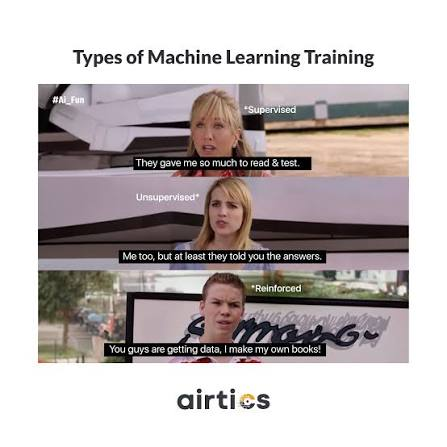

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Affichage adapte aux petits ecrans
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 80)

# Les donnees sont lues directement depuis le web : rien a telecharger
BASE = "https://raw.githubusercontent.com/maxischa/Intelligence-Artificielle-et-Data-Science/main/bloc3_ml/data/"

La cellule de setup s'est allongée : elle charge une bibliothèque de plus,
**scikit-learn** (`sklearn`).

C'est la boîte à outils standard du machine learning en Python : les modèles,
le découpage entraînement / test, et les mesures qui disent si un modèle est
bon. Elle est déjà installée dans Colab, il n'y a rien à télécharger.

On n'importe pas `sklearn` en entier, seulement les morceaux dont on a besoin —
d'où les `from sklearn.<...> import <...>` de la cellule. Tous suivent la même
logique, et vous les retrouverez ligne par ligne au fil de la séance :

| Ce qu'on importe | À quoi ça sert |
|---|---|
| `train_test_split` | mettre de côté une partie des données pour évaluer sa performance |
| `LinearRegression`, `LogisticRegression` | les deux modèles de la séance |
| `StandardScaler`, `make_pipeline` | mettre les colonnes à la même échelle, et enchaîner des étapes de traitement de données |
| `mean_absolute_error`, `r2_score`, … | les notes qu'on donne à un modèle pour l'évaluer |

## 1. Prédire un nombre : la régression linéaire

Le cas le plus simple : une seule variable d'entrée. Combien rapporte une
commande, sachant le nombre d'unités qu'elle contient ?

In [ ]:
cmd = pd.read_csv(BASE + "commandes.csv")

X1 = cmd[["qte"]]   ## l'unique information connue avant de facturer
yr = cmd["ca"]      ## ce que l'on veut prevoir

print(X1.shape, yr.shape)

In [ ]:
# Ajustement de la regression lineaire simple (OLS) : ca ~ qte
ols = LinearRegression().fit(X1, yr)

# Une grille triee permet de tracer une droite continue de gauche a droite
grille = pd.DataFrame({"qte": np.linspace(X1["qte"].min(), X1["qte"].max(), 200)})

plt.figure(figsize=(7, 4))
plt.scatter(X1["qte"], yr, s=18, alpha=0.25, color="#2878B5", label="Commandes")
plt.plot(grille["qte"], ols.predict(grille), color="#D64541", linewidth=3,
         label="Droite OLS")
plt.xlabel("Quantite commandee (qte)")
plt.ylabel("Chiffre d'affaires (ca, en euros)")
plt.legend()
plt.tight_layout()
plt.show()

La droite résume le nuage. Elle tient en **deux nombres** : une pente et une
constante. Allons les lire.

In [ ]:
print(f"Constante          : {ols.intercept_:.2f} euros")
print(f"Coefficient de qte : {ols.coef_[0]:.2f} euros par article")
print(f"Equation estimee   : ca = {ols.intercept_:.2f} + {ols.coef_[0]:.2f} x qte")
print(f"R2 sur ces donnees : {ols.score(X1, yr):.3f}")

**1,44 € par article.** Chaque unité commandée en plus est associée à 1,44 €
de chiffre d'affaires supplémentaire. Ça, c'est de l'**explication** : on décrit
une relation observée.

> ⚠️ **La constante ne se lit pas comme un montant.** 114,59 € est ce que le
> modèle prédirait pour une commande de **zéro** unité — une commande qui
> n'existe pas. La constante **positionne la droite**, elle ne décrit aucun
> client. C'est le premier nombre de modèle que vous rencontrez qui ne veut
> rien dire tout seul ; il y en aura d'autres.

Le **R² = 0,719** dit que la droite reproduit 72 % de la variation du chiffre
d'affaires. Question à se poser tout de suite : **sur quelles lignes ce 0,719
a-t-il été calculé ?**

## 2. Noter un modèle : le découpage apprentissage / test

Un modèle noté sur les données qui l'ont produit **se note lui-même**. C'est
réviser sur l'annale, puis passer cette annale-là comme examen : le résultat
est excellent et ne prédit rien.

La parade tient en une ligne : on met des lignes **de côté**, on n'y touche
pas pendant l'apprentissage, et on note dessus.

In [ ]:
Xr = cmd[["qte", "nart"]]   ## deux variables, cette fois

# test_size=0.25 : un quart des lignes mises de cote pour la notation
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    Xr, yr, test_size=0.25, random_state=67)

print("Jeu d'apprentissage :", len(Xr_tr), "commandes")
print("Jeu de test         :", len(Xr_te), "commandes")

In [ ]:
reg = LinearRegression().fit(Xr_tr, yr_tr)   ## on apprend sur le train

pr_tr = reg.predict(Xr_tr)   ## sur ce qu'il a vu
pr_te = reg.predict(Xr_te)   ## sur ce qu'il n'a jamais vu

print(pd.DataFrame({"ca_observe": yr_te.iloc[:5].values,
                    "ca_predit": pr_te[:5]}).round(2))

### Trois notes, et deux d'entre elles sont en euros

In [ ]:
print(f"MAE  apprentissage {mean_absolute_error(yr_tr, pr_tr):8.1f}  "
      f"test {mean_absolute_error(yr_te, pr_te):8.1f}  euros")
print(f"RMSE apprentissage {mean_squared_error(yr_tr, pr_tr) ** 0.5:8.1f}  "
      f"test {mean_squared_error(yr_te, pr_te) ** 0.5:8.1f}  euros")
print(f"R2   apprentissage {r2_score(yr_tr, pr_tr):8.3f}  "
      f"test {r2_score(yr_te, pr_te):8.3f}")

| Mesure | Ce qu'elle dit | Unité |
|---|---|---|
| **MAE** | l'erreur moyenne, toutes les fautes comptant pareil | des euros |
| **RMSE** | l'erreur moyenne, les **grosses** fautes comptant beaucoup plus | des euros |
| **R²** | la part de la variation reproduite ; 0 = « aussi bon que prédire la moyenne » | sans unité |

Les trois formules, avec $y_i$ la valeur observée, $\hat{y}_i$ la valeur
prédite, $\bar{y}$ la moyenne des observées et $n$ le nombre d'observations :

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert$$

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

Deux choses à lire ici :

1. **L'apprentissage est meilleur que le test.** Toujours. Les coefficients ont
   été calculés pour coller à ces lignes-là. Quelques points d'écart sont le
   prix normal ; un écart béant s'appellerait du **surapprentissage** — le
   modèle aurait retenu au lieu d'apprendre.
2. **La RMSE vaut plus du double de la MAE.** Elle élève les erreurs au carré
   avant de les moyenner : une faute de 2 000 € y pèse cent fois une faute de
   200 €. L'écart entre les deux est un signal — une poignée de commandes est
   très mal prédite.

> 💡 **MAE et RMSE se citent en réunion, le R² non.** « Nous nous trompons de
> 218 € sur un panier médian de 343 € » est une phrase de gestion.

## 3. L'erreur qui donne un modèle parfait — et inutile

Ajoutons `ca` aux variables explicatives. C'est-à-dire : donnons la réponse au
modèle.

In [ ]:
fuite = cmd[["qte", "nart", "ca"]]   ## "ca" est la reponse elle-meme
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(fuite, yr, test_size=0.25,
                                              random_state=67)

parfait = LinearRegression().fit(Xf_tr, yf_tr)
print("R2 :", round(r2_score(yf_te, parfait.predict(Xf_te)), 6))

**R² = 1,0.** Un modèle parfait, et strictement inutile : le jour où une vraie
commande arrive, la colonne `ca` n'existe pas encore.

C'est une **fuite de données**, et c'est l'erreur la plus coûteuse de tout le
domaine — parce qu'elle ne lève aucune alerte. Elle donne un excellent modèle,
qu'on déploie, et qui s'effondre en production.

> ⚠️ **Le test à appliquer, systématiquement :** cette colonne existerait-elle
> **avant** que le fait à prédire ne se produise ? Si non, elle n'a rien à
> faire dans `X`. La fuite est rarement aussi visible qu'ici — la question 8
> de la feuille en montre une réaliste.

---

## 4. Prédire une décision : la régression logistique

Nouveau fichier, nouvelle question. Un opérateur télécom, 7 043 abonnés, et
une seule chose à prévoir : **cet abonné va-t-il résilier ?**

La réponse n'est plus un montant, c'est **oui ou non**.

La **régression logistique** produit une **probabilité**, entre 0 et 1, qu'une
personne va résilier, alors que la régression linéaire peut produire des
probabilités en dessous de 0 ou au-dessus de 1. Une probabilité de résilier
supérieure à 1 (c'est-à-dire 100 %) est insensée. Et que voudrait dire une
probabilité en dessous de zéro ?

En conséquence, le modèle logistique est plus adapté aux prédictions de
décision (résiliation : oui ou non ; reconduite d'un contrat : oui ou non).
Le modèle nous donne une probabilité pour l'événement « oui » qui a un sens,
c'est-à-dire comprise entre 0 et 1.

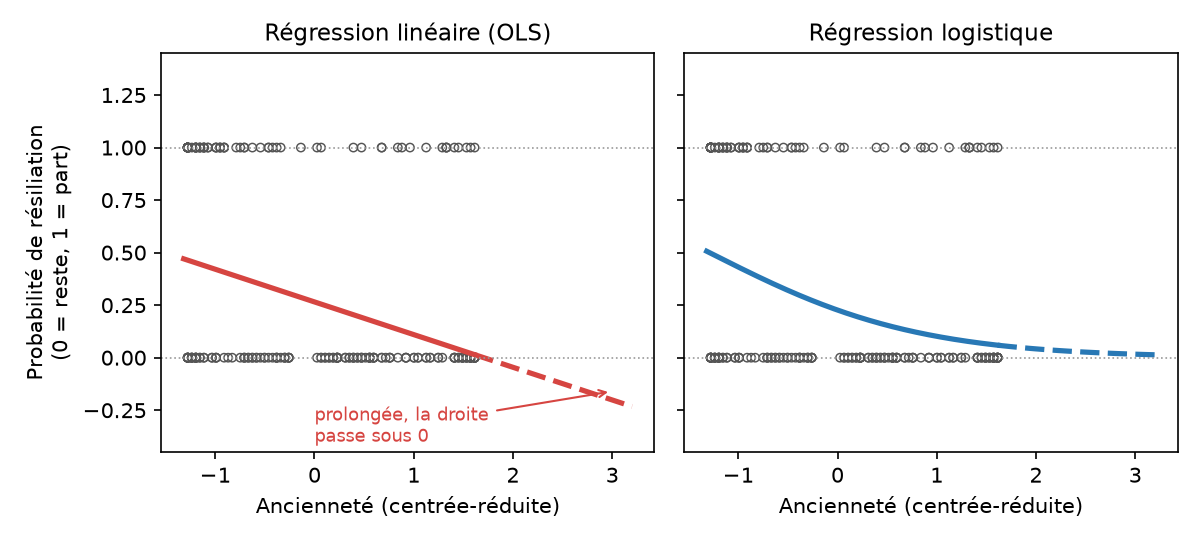

In [ ]:
tel = pd.read_csv(BASE + "churn.csv")   ## une ligne = un abonne

# `total` arrive en TEXTE, avec onze cases vides : le nettoyage du bloc 2
tel["total"] = pd.to_numeric(tel["total"], errors="coerce")   ## coerce -> NaN
print(tel["total"].isna().sum(), "valeurs vides ->", end=" ")
tel = tel.dropna(subset=["total"])
print(len(tel), "abonnes conserves")

# La moyenne d'une colonne de 0 et de 1, c'est la proportion de 1
print("taux de resiliation :", round(100 * tel["churn"].mean(), 1), "%")

### Les variables texte n'entrent pas dans un modèle

La variable `contrat` vaut `mensuel`, `un_an` ou `deux_ans`. Un modèle ne sait pas
multiplier du texte par un coefficient. La cellule suivante est
**volontairement fausse**.

In [ ]:
LogisticRegression().fit(tel.drop(columns=["churn"]), tel["churn"])

`ValueError: could not convert string to float: 'mensuel'`. Il faut donc
**transformer chaque modalité en une colonne de 0 et de 1** : c'est ce que fait
`get_dummies`.

In [ ]:
yc = tel["churn"]   ## la cible : 1 = parti
Xc = pd.get_dummies(tel.drop(columns=["churn"]), drop_first=True)

print(Xc.shape[1], "colonnes apres transformation")   ## 9 -> 14
list(Xc.columns)

> 💡 **`drop_first=True` et la modalité de référence.** Pour un contrat, deux
> colonnes suffisent : `contrat_un_an` et `contrat_deux_ans`. Si ce n'est ni
> l'un ni l'autre, c'est forcément « mensuel » — la troisième colonne
> n'apporterait aucune information. La modalité qu'on ne code pas s'appelle la
> **modalité de référence**, et tous les coefficients se lisent *par rapport à
> elle*.

In [ ]:
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.3, random_state=42, stratify=yc)

# stratify : garder le meme taux de resiliation des deux cotes du decoupage
print(round(100 * yc_tr.mean(), 1), "% de churn en apprentissage |",
      round(100 * yc_te.mean(), 1), "% en test")

In [ ]:
# StandardScaler d'abord : l'anciennete va de 0 a 72, la facture cumulee
# de 18 a 8 700. Sans mise a l'echelle, l'optimisation converge mal.
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(Xc_tr, yc_tr)

# predict_proba renvoie deux colonnes : [proba de rester, proba de partir]
proba = clf.predict_proba(Xc_te)[:, 1]   ## l'indice 1 : la proba de PARTIR
print("probabilite de depart des 5 premiers :", proba[:5].round(3))

## 5. Évaluer une décision : les quatre cases

`predict` tranche à 0,50 : au-dessus, « il part ». Croisons la prédiction avec
la vérité.

In [ ]:
pred = clf.predict(Xc_te)   ## predict tranche a 0,50 par defaut

pd.DataFrame(confusion_matrix(yc_te, pred),
             index=["reste vraiment", "part vraiment"],
             columns=["predit reste", "predit part"])

Deux façons de se tromper, et elles ne coûtent pas la même chose :

| Erreur | Ce que c'est | Ce que ça coûte ici |
|---|---|---|
| **Faux positif** | on appelle quelqu'un qui n'allait pas partir | un appel — 15 € |
| **Faux négatif** | on laisse partir quelqu'un sans rien tenter | un client — ~90 € de marge |

Un faux négatif coûte **six fois** un faux positif. Retenez-le pour la section
suivante.

In [ ]:
print("justesse  :", round(accuracy_score(yc_te, pred), 3))
print("precision :", round(precision_score(yc_te, pred), 3))
print("rappel    :", round(recall_score(yc_te, pred), 3))
print("F1        :", round(f1_score(yc_te, pred), 3))

| Mesure | La question à laquelle elle répond |
|---|---|
| **justesse** | quelle part de mes prédictions est correcte ? |
| **précision** | parmi ceux dont je prédis qu'ils partent, combien partaient vraiment ? |
| **rappel** | parmi ceux qui partent, combien ai-je prédits correctement ? |
| **F1** | les deux précédentes en un seul nombre |

79,8 % de justesse : plutôt bien ? Comparons au modèle le plus bête du monde.

In [ ]:
# Il repond toujours "reste", quoi qu'on lui donne
print("toujours predire 'reste' :", round(100 * (1 - yc_te.mean()), 1), "%")

> ⚠️ **73,4 % sans aucun modèle.** Notre travail apporte **six points** de
> justesse, pas 80. Dès que les classes sont déséquilibrées — et une
> résiliation est rare par nature — **la justesse est un piège**. C'est le
> rappel qui compte ici : nous ne retrouvons qu'un partant sur deux.
>
> **Toujours calculer ce que score le modèle le plus bête avant de se
> réjouir.** Si vous ne retenez qu'une habitude de la journée, prenez
> celle-là.

## 6. Le seuil est une décision de gestion

`predict` tranche à 0,50 et prédit une résiliation (un départ) si la
probabilité estimée par le modèle qu'un client parte est supérieure à 50 %
(0,50). Il faut bien trancher quelque part, mais rien n'oblige à garder ce
chiffre.

In [ ]:
for seuil in [0.5, 0.4, 0.3, 0.2]:
    p = (proba > seuil).astype(int)   ## True/False -> 1/0
    print(f"seuil {seuil} : rappel {recall_score(yc_te, p):.2f}  "
          f"precision {precision_score(yc_te, p):.2f}  "
          f"F1 {f1_score(yc_te, p):.2f}  contacts {p.sum()}")

Le rappel monte, la précision descend : on retrouve plus de partants, en
appelant plus de gens pour rien. Ce compromis n'a **pas** de solution
technique. Il en a une économique.

In [ ]:
# 15 EUR l'appel, 300 EUR de valeur client, 30 % des relances aboutissent
for seuil in [0.5, 0.4, 0.3, 0.2, 0.1]:
    p = (proba > seuil).astype(int)
    vrais = ((p == 1) & (yc_te == 1)).sum()   ## partants effectivement rattrapes
    gain = vrais * 0.30 * 300 - p.sum() * 15
    print(f"seuil {seuil} : {p.sum():>4} appels, {vrais:>3} vrais partants "
          f"-> {gain:>8.0f} euros")

**L'optimum est à 0,20, pas à 0,50.** Le seuil par défaut coûtait environ
8 000 € par rapport au meilleur réglage — et aucune mesure statistique ne
l'aurait signalé, parce que le F1 est presque plat sur toute la plage.

> **Un modèle ne décide pas, il informe.** Il produit une probabilité ; c'est
> le coût des deux erreurs qui fixe le seuil. Changez le coût d'un appel, et
> le bon seuil change avec.

---

La séance 3.2 quitte le supervisé : il n'y aura plus de bonne réponse à
laquelle se comparer, et il faudra quand même décider.

---

## Ce que vous savez faire maintenant

| Vous voulez... | La commande |
|---|---|
| découper les données | `train_test_split(X, y, test_size=0.25, random_state=67)` |
| garder les mêmes proportions | `train_test_split(..., stratify=y)` |
| ajuster une régression | `LinearRegression().fit(X_tr, y_tr)` |
| lire ce qu'elle a appris | `reg.coef_`, `reg.intercept_` |
| l'erreur moyenne, en euros | `mean_absolute_error(y_te, p)` |
| l'erreur qui punit les grosses fautes | `mean_squared_error(y_te, p) ** 0.5` |
| la part expliquée | `r2_score(y_te, p)` |
| du texte en colonnes utilisables | `pd.get_dummies(df, drop_first=True)` |
| une régression logistique | `make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))` |
| une **probabilité** plutôt qu'une classe | `clf.predict_proba(X_te)[:, 1]` |
| décider à un autre seuil | `(proba > 0.30).astype(int)` |
| les quatre cases | `confusion_matrix(y_te, pred)` |
| les trois taux | `precision_score`, `recall_score`, `f1_score` |

## Les cinq phrases à retenir

1. **Un modèle noté sur les données qui l'ont produit se note lui-même.** La
   seule note qui compte est celle obtenue sur des lignes jamais vues.

2. **RMSE et MAE se lisent en euros.** « Je me trompe de 218 € en moyenne » est
   une phrase de gestion ; « R² = 0,69 » n'en est pas une.

3. **Une variable qui contient la réponse donne un modèle parfait et inutile.**
   Le test : cette colonne existerait-elle **avant** que le fait à prédire ne
   se produise ?

4. **La justesse est un piège dès que les classes sont déséquilibrées.** Ici,
   prédire « personne ne part » donne déjà 73,4 %.

5. **Le seuil n'est pas un réglage technique, c'est une décision de gestion.**
   Il se choisit sur le coût des deux erreurs, jamais sur une habitude.